# Zelda-NCA: Topology-Preserving Level Repair with Neural Cellular Automata

This notebook walks through the whole project, from the raw corpus to the figures of the
report. It runs on Kaggle, Colab or locally, and by default loads the trained
checkpoints rather than retraining: set the `SKIP_TRAINING_*` flags to `False` to train
from scratch.

All logic lives in `src/`; the notebook calls it. The training entry point is
`scripts/train.py` and the evaluation entry point is `scripts/evaluate.py`, both driven
by the configuration files under `conf/`.

**Question.** Can a purely local update rule, trained only to reconstruct real dungeon
rooms, restore the playability of a damaged one? Connectivity never appears in the loss,
so whatever the model preserves it has not been told to preserve.

## 1. Environment detection and paths

In [1]:
import os
import sys

if os.path.exists("/kaggle/working"):
    ENVIRONMENT = "kaggle"
    BASE_DIR = "/kaggle/working"
elif "google.colab" in sys.modules:
    ENVIRONMENT = "colab"
    BASE_DIR = "/content"
else:
    ENVIRONMENT = "local"
    BASE_DIR = os.path.abspath("..")

print(f"environment: {ENVIRONMENT}")
print(f"base directory: {BASE_DIR}")

environment: kaggle
base directory: /kaggle/working


## 2. Repository and Python path

In [2]:
GITHUB_REPO_URL = "https://github.com/NicoPozio/zelda-nca.git"
REPO_DIR = os.path.join(BASE_DIR, "zelda-nca") if ENVIRONMENT != "local" else BASE_DIR

if ENVIRONMENT != "local":
    if not os.path.exists(REPO_DIR):
        !git clone -q {GITHUB_REPO_URL} {REPO_DIR}
    else:
        !cd {REPO_DIR} && git pull -q

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f"working directory: {os.getcwd()}")

working directory: /kaggle/working/zelda-nca


## 3. Dependencies

In [3]:
if ENVIRONMENT in ("kaggle", "colab"):
    !pip install -q hydra-core
print("done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 3.0 MB/s eta 0:00:00
done


## 4. Checkpoints

Training every configuration of the study takes several hours on a T4. The checkpoints
are published as a Kaggle dataset; when it is mounted, the notebook loads from there.

In [4]:
import glob
import shutil

RUNS_DIR = os.path.join(BASE_DIR, "runs")

sources = glob.glob("/kaggle/input/**/runs", recursive=True)
if sources and not os.path.exists(RUNS_DIR):
    os.makedirs(RUNS_DIR, exist_ok=True)
    for src in sources:
        for d in os.listdir(src):
            if os.path.isdir(f"{src}/{d}") and not os.path.exists(f"{RUNS_DIR}/{d}"):
                shutil.copytree(f"{src}/{d}", f"{RUNS_DIR}/{d}")

CHECKPOINTS_AVAILABLE = os.path.isdir(RUNS_DIR) and len(os.listdir(RUNS_DIR)) > 0
print(f"checkpoints available: {CHECKPOINTS_AVAILABLE}")
if CHECKPOINTS_AVAILABLE:
    print(f"runs found: {len(os.listdir(RUNS_DIR))}")

SKIP_TRAINING_NCA   = CHECKPOINTS_AVAILABLE   # set to False to retrain
SKIP_TRAINING_UNET  = CHECKPOINTS_AVAILABLE
SKIP_TRAINING_ABLATIONS = True                # the full sweep is 46 runs

checkpoints available: True
runs found: 77


## 5. Imports and global setup

In [5]:
import csv
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from src.damage.stochastic import erasure, tile_flip
from src.damage.targeted import TARGETED, kill_cells
from src.data.augment import augment
from src.data.dedup import deduplicate
from src.data.splits import train_val_test_split
from src.data.symmetry import symmetries
from src.data.vglc import extract_rooms, parse_dungeon
from src.metrics.connectivity import (access_mask, main_component_mask,
                                      preserves_topology, probe_mask, rsr,
                                      tile_accuracy, walkable_components)
from src.models.aux_targets import access_distance_field
from src.models.encoding import decode, to_nca_state, visible_channels
from src.models.nca import NCA, _perception_filters
from src.models.unet import UNet
from src.tiles import CHAR_MAP, IDX_TO_CHAR, NUM_TILES, RAW_COLS, RAW_ROWS, walkable_mask
from src.train.pool import SamplePool
from src.train.trainer import Trainer
from src.viz import parse_room, render_components, render_mask, render_room

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
plt.rcParams.update({"figure.dpi": 130, "font.size": 9})

print(f"device: {device}")
print(f"torch: {torch.__version__}")

device: cuda
torch: 2.10.0+cu128


## 6. The corpus

The Video Game Level Corpus provides the nine dungeons of the first quest as text files,
one character per tile. A room occupies a block of 16 rows by 11 columns in the file.

In [6]:
!python scripts/prepare_data.py

rooms, sources_tag = extract_rooms("data/raw", to_visual=True)
unique = deduplicate(rooms, mode="symmetry")

print(f"\nrooms extracted: {len(rooms)}")
print(f"unique up to symmetry: {len(unique)}")
print(f"\ntile alphabet:")
for char, idx in sorted(CHAR_MAP.items(), key=lambda kv: kv[1]):
    print(f"  {idx}  {char}")

estratte 236 stanze, 136 uniche (dedup=symmetry)
salvate in data/processed/rooms.npz  ->  array (136, 11, 16)

rooms extracted: 236
unique up to symmetry: 136

tile alphabet:
  0  F
  1  B
  2  M
  3  P
  4  O
  5  I
  6  D
  7  S
  8  W
  9  -


## 7. Storage orientation is transposed with respect to the game

The corpus stores each room as 16 rows by 11 columns, while the game presents it as 11
by 16. We verified this against the published map of dungeon 1: a black room in the upper
middle of the file corresponds to the middle left of the map, and the pinwheel room and
the right-hand cluster line up only after transposing.

The transpose preserves 4-adjacency, so topology is unaffected. It is a display
convention adopted so that the figures read the way the game looks.

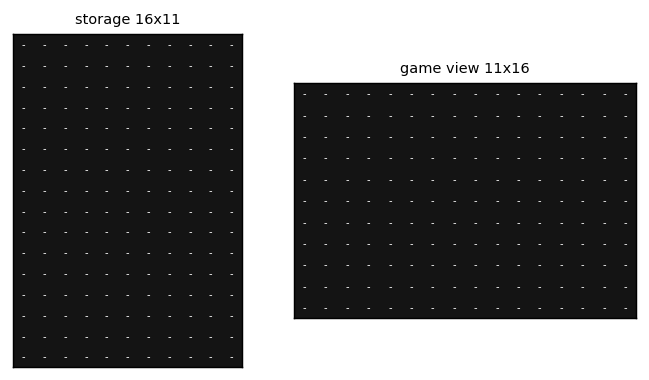

In [7]:
grid = parse_dungeon("data/raw/tloz1_1.txt")
raw = grid[:RAW_ROWS, :RAW_COLS]

fig, axes = plt.subplots(1, 2, figsize=(5.5, 3))
render_room(raw, axes[0], f"storage {raw.shape[0]}x{raw.shape[1]}", letters=True)
render_room(raw.T, axes[1], f"game view {raw.T.shape[0]}x{raw.T.shape[1]}", letters=True)
plt.tight_layout()

## 8. Traversability, and the two traps

`O` is shallow water and is walkable: treating it as an obstacle would split rooms that
are perfectly traversable.

`-` is overloaded. In rooms with a black background it is the walkable floor; in rooms
that contain actual floor it is a pit. The rule that resolves the ambiguity is
contextual: void counts as walkable only when the room contains no floor tile at all.

black-background rooms (void is floor): 24
rooms with floor and void  (void is a pit): 2


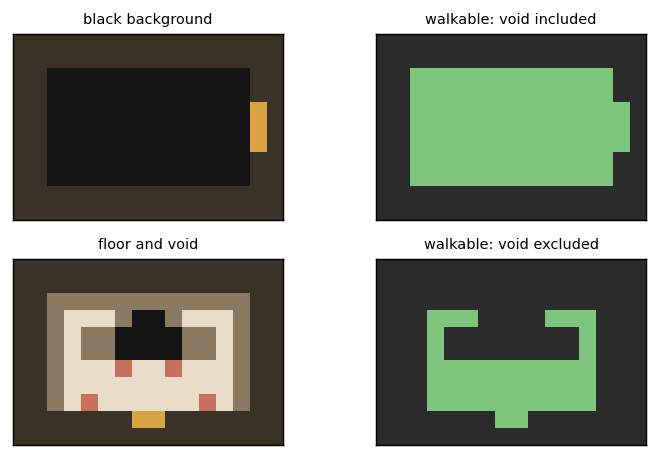

In [8]:
F_IDX, VOID = CHAR_MAP["F"], CHAR_MAP["-"]

black = [r for r in rooms if not np.any(r == F_IDX) and np.any(r == VOID)]
pit = [r for r in rooms if np.any(r == F_IDX) and np.any(r == VOID)]
print(f"black-background rooms (void is floor): {len(black)}")
print(f"rooms with floor and void  (void is a pit): {len(pit)}")

fig, axes = plt.subplots(2, 2, figsize=(6, 3.6))
render_room(black[0], axes[0][0], "black background")
render_mask(walkable_mask(black[0]), axes[0][1], "walkable: void included")
render_room(pit[0], axes[1][0], "floor and void")
render_mask(walkable_mask(pit[0]), axes[1][1], "walkable: void excluded")
plt.tight_layout()

## 9. No content filtering

Rooms without doors were discarded twice during the project and reinstated both times.
The first filter kept only rooms with a door; eight of the discarded rooms turned out to
contain a stair. That was wrong as well, since stairs do not connect rooms of the
dungeon, and the doorless rooms are secret rooms whose walls are bombable. They are
traversable, and in some cases required to finish the dungeon.

The corpus does not annotate bombable walls. Filtering on their absence discards
legitimate rooms because of a limitation of the dataset, not of the rooms.

rooms with no door and no stair: 12 (all kept)


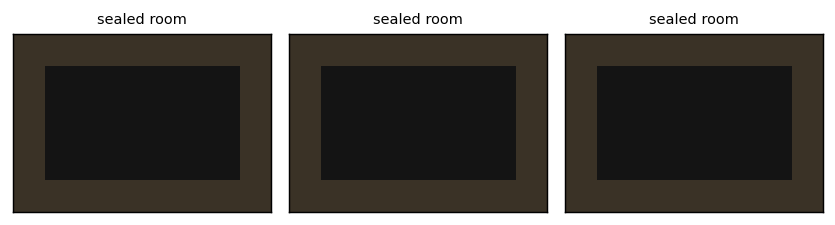

In [9]:
D, S = CHAR_MAP["D"], CHAR_MAP["S"]
sealed = [r for r in rooms if not np.any(r == D) and not np.any(r == S)]
print(f"rooms with no door and no stair: {len(sealed)} (all kept)")

fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.2))
for ax, r in zip(axes, sealed[:3]):
    render_room(r, ax, "sealed room")
plt.tight_layout()

## 10. Deduplication, split and augmentation

The game reuses layouts across dungeons, sometimes mirrored, so deduplication runs before
the split: a room and its mirror cannot land on opposite sides of it. Augmentation
applies the four shape-preserving symmetries to the training split only.

In [10]:
train, val, test = train_val_test_split(unique, 0.15, 0.15, seed=42)
train_aug = augment(train)

print(f"{len(rooms)} rooms -> {len(unique)} unique")
print(f"split: train {len(train)}  val {len(val)}  test {len(test)}")

self_sym = sum(1 for r in train if len({s.tobytes() for s in symmetries(r)}) < 4)
distinct = len({x.tobytes() for x in train_aug})
print(f"\naugmented: {len(train_aug)} samples, {distinct} distinct "
      f"({distinct / len(train):.2f}x rather than 4x)")
print(f"self-symmetric training rooms: {self_sym} of {len(train)}")

train_keys = {x.tobytes() for x in train}
leaks = sum(any(s.tobytes() in train_keys for s in symmetries(x))
            for x in list(val) + list(test))
print(f"symmetry leakage into training: {leaks}")

236 rooms -> 136 unique
split: train 96  val 20  test 20

augmented: 384 samples, 229 distinct (2.39x rather than 4x)
self-symmetric training rooms: 67 of 96
symmetry leakage into training: 0


## 11. Why the metric is relative to the pristine room

An absolute criterion would ask that every access be reachable from the interior. Applied
to pristine rooms it fails on a number of them, because the corpus annotates geometry but
not affordances: pushable blocks, bombable walls and items that make water traversable
are not marked.

Reachability through movable blocks is the solution of a planning problem, not a static
property of the graph, so annotating the tiles would not remove the ambiguity. The
criterion is therefore defined relative to the pristine room.

pristine rooms where a naive search cannot reach an access: 21


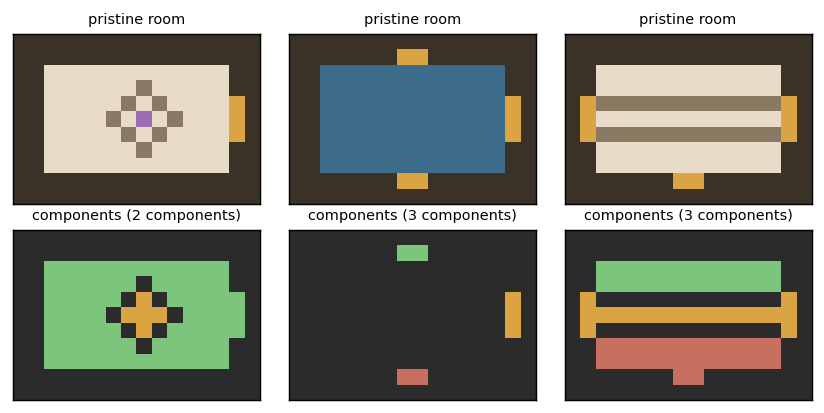

In [11]:
def all_access_reachable(room):
    labels, n = walkable_components(room)
    acc = access_mask(room)
    if n == 0 or not acc.any():
        return None
    main = main_component_mask(room)
    return bool(np.all(labels[acc] == labels[main][0]))


failing = [r for r in unique if all_access_reachable(r) is False]
print(f"pristine rooms where a naive search cannot reach an access: {len(failing)}")

fig, axes = plt.subplots(2, 3, figsize=(6.5, 3.2))
for k, r in enumerate(failing[:3]):
    render_room(r, axes[0][k], "pristine room")
    render_components(r, axes[1][k], "components")
plt.tight_layout()

## 12. The criterion in practice

Two conditions, both necessary. The accesses must be exactly those of the original, and
the probe cells must fall into the same connected components. Probes are the main
walkable component together with every access, including accesses outside that
component.

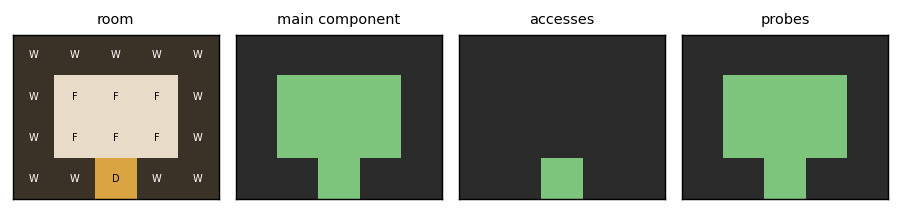

In [12]:
room = parse_room(["WWWWW", "WFFFW", "WFFFW", "WWDWW"])

fig, axes = plt.subplots(1, 4, figsize=(7, 1.9))
render_room(room, axes[0], "room", letters=True)
render_mask(main_component_mask(room), axes[1], "main component")
render_mask(access_mask(room), axes[2], "accesses")
render_mask(probe_mask(room), axes[3], "probes")
plt.tight_layout()

In [13]:
cases = [("identical copy", True), ("access walled off", False),
         ("access turned into floor", False), ("wall in front of the access", False),
         ("extra access", False), ("monster added on floor", True)]
variants = [room.copy() for _ in cases]
variants[1][3, 2] = CHAR_MAP["W"]
variants[2][3, 2] = CHAR_MAP["F"]
variants[3][2, 2] = CHAR_MAP["W"]
variants[4][0, 2] = CHAR_MAP["D"]
variants[5][1, 1] = CHAR_MAP["M"]

print(f"{'case':<32}{'expected':>10}{'measured':>10}")
print("-" * 52)
for (label, expected), variant in zip(cases, variants):
    print(f"{label:<32}{str(expected):>10}{str(preserves_topology(room, variant)):>10}")

case                              expected  measured
----------------------------------------------------
identical copy                        True      True
access walled off                    False     False
access turned into floor             False     False
wall in front of the access          False     False
extra access                         False     False
monster added on floor                True      True


## 13. The case the relative criterion exists for

This layout occurs several times in the corpus: a spiral of blocks around a central
stair. The stair is unreachable by a naive search even in the pristine room, because the
blocks are pushable and the corpus does not say so.

Under the relative criterion the pristine room passes, since the repaired room only has
to reproduce the original grouping. The converse also holds: a model that opens the wall
and connects the stair changes the grouping and fails, so it cannot game the metric by
improving the topology.

pristine against itself: True
stair wrongly connected: False


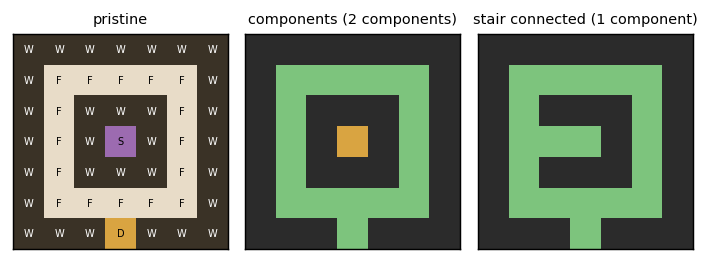

In [14]:
spiral = parse_room(["WWWWWWW", "WFFFFFW", "WFWWWFW", "WFWSWFW",
                     "WFWWWFW", "WFFFFFW", "WWWDWWW"])
opened = spiral.copy()
opened[3, 2] = CHAR_MAP["F"]

fig, axes = plt.subplots(1, 3, figsize=(5.5, 2))
render_room(spiral, axes[0], "pristine", letters=True)
render_components(spiral, axes[1], "components")
render_components(opened, axes[2], "stair connected")
plt.tight_layout()

print(f"pristine against itself: {preserves_topology(spiral, spiral.copy())}")
print(f"stair wrongly connected: {preserves_topology(spiral, opened)}")

## 14. Tile accuracy is blind to functional failure

A single wrong tile in front of the access leaves accuracy above ninety percent and the
room without a usable exit. This is the observation the topological metric exists for,
and it is asserted in the test suite so that it is checked on every run.

tile accuracy:      0.950
topology preserved: False


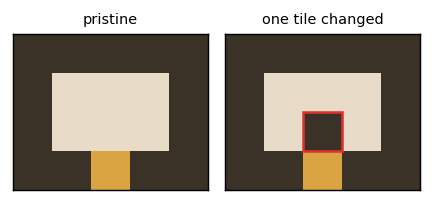

In [15]:
blocked = room.copy()
blocked[2, 2] = CHAR_MAP["W"]

fig, axes = plt.subplots(1, 2, figsize=(3.4, 1.9))
render_room(room, axes[0], "pristine")
render_room(blocked, axes[1], "one tile changed", highlight=(room != blocked))
plt.tight_layout()

print(f"tile accuracy:      {tile_accuracy([room], [blocked]):.3f}")
print(f"topology preserved: {preserves_topology(room, blocked)}")

## 15. The damage taxonomy

Training damage is stochastic: a contiguous patch erased, or scattered tiles replaced by
a wrong category. Evaluation damage is targeted and never appears in training, so that
repairing it tests generalisation rather than memorisation. The two families live in
separate modules, which makes it structurally impossible to use a targeted damage during
training.

B1 destroys 3 cells, B3 destroys 3;
the matched-extent control A3 destroys the same number, chosen at random.


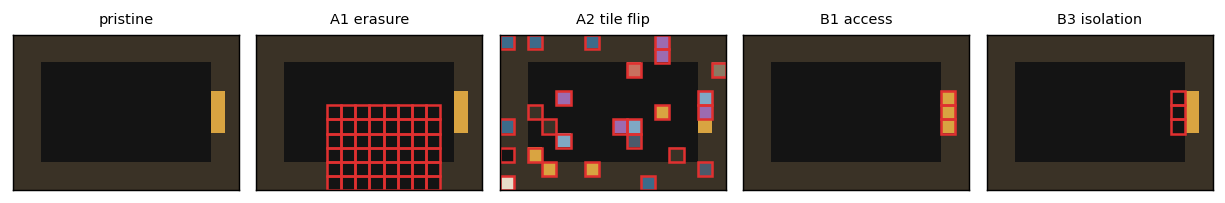

In [16]:
sample = unique[0]
state = to_nca_state(torch.as_tensor(sample).unsqueeze(0), 12)
rng = np.random.default_rng(0)

eras, mask_e = erasure(state, np.random.default_rng(0), 0.25)
flip, mask_f = tile_flip(state, np.random.default_rng(0), 0.15)
door_mask_t = TARGETED["B1_door"](sample, np.random.default_rng(0), n_doors=1)
iso_mask = TARGETED["B3_isolation"](sample, np.random.default_rng(0))

fig, axes = plt.subplots(1, 5, figsize=(9.5, 1.9))
render_room(sample, axes[0], "pristine")
render_room(decode(eras)[0].numpy(), axes[1], "A1 erasure", highlight=mask_e[0, 0].numpy())
render_room(decode(flip)[0].numpy(), axes[2], "A2 tile flip", highlight=mask_f[0, 0].numpy())
render_room(sample, axes[3], "B1 access", highlight=door_mask_t)
render_room(sample, axes[4], "B3 isolation", highlight=iso_mask)
plt.tight_layout()

print(f"B1 destroys {int(door_mask_t.sum())} cells, B3 destroys {int(iso_mask.sum())};")
print("the matched-extent control A3 destroys the same number, chosen at random.")

## 16. The cellular rule

Each cell holds 22 channels, ten one-hot tiles and twelve hidden, and perceives its
neighbourhood through three fixed filters applied to every channel independently. The
filters are not learned: the model learns how to react to its neighbourhood, not what to
look at.

filter bank: (66, 1, 3, 3) (3 filters x 22 channels)
trainable parameters: 11,414


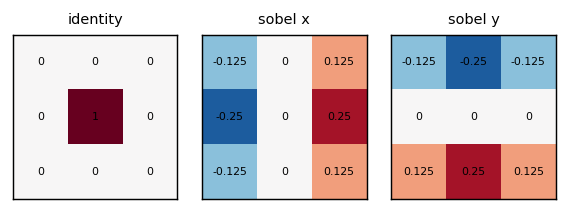

In [17]:
nca = NCA(hidden_channels=12)
filters = _perception_filters(1)

fig, axes = plt.subplots(1, 3, figsize=(4.5, 1.6))
for ax, f, name in zip(axes, filters, ["identity", "sobel x", "sobel y"]):
    ax.imshow(f[0], cmap="RdBu_r", vmin=-0.3, vmax=0.3)
    for (i, j), v in np.ndenumerate(f[0].numpy()):
        ax.text(j, i, f"{v:.3g}", ha="center", va="center", fontsize=6)
    ax.set_title(name, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

print(f"filter bank: {tuple(nca.filters.shape)} "
      f"({nca.filters.shape[0] // nca.num_channels} filters x {nca.num_channels} channels)")
print(f"trainable parameters: {sum(p.numel() for p in nca.parameters()):,}")

## 17. Border padding, checked against an external property

A Sobel filter sums to zero, so its response on a constant region must be exactly zero.
That is a property of the operator, independent of the implementation, which makes it a
usable check.

With zero padding the property fails at the border: the convolution reports an edge that
does not exist. The original formulation grows a figure inside a larger canvas, where the
border is empty and this never matters. Rooms fill the grid to the perimeter, and the
perimeter cells are exactly the ones that define the enclosure.

In [18]:
constant = torch.ones(1, nca.num_channels, 8, 8)

zero_pad = F.conv2d(F.pad(constant, (1, 1, 1, 1), mode="constant", value=0.0),
                    nca.filters, groups=nca.num_channels)
repl_pad = nca.perceive(constant)


def sobel_energy(perceived):
    return float(perceived.reshape(1, nca.num_channels, 3, 8, 8)[:, :, 1:3].abs().sum())


print("sobel response on a constant region")
print(f"  zero padding:      {sobel_energy(zero_pad):.4f}")
print(f"  replicate padding: {sobel_energy(repl_pad):.4f}")

sobel response on a constant region
  zero padding:      330.0000
  replicate padding: 0.0000


## 18. Locality

The property the whole project turns on. Perturbing one cell and taking a single step
must leave every cell outside its immediate neighbourhood untouched. This is measured,
not assumed from the architecture.

cells changed in total:              9
cells changed outside the 3x3 patch: 0


[]

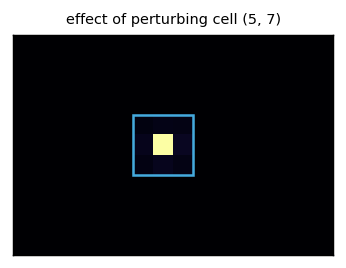

In [19]:
probe = NCA(hidden_channels=12)
probe.update_prob = 1.0
nn.init.normal_(probe.w2.weight, std=0.1)

s1 = to_nca_state(torch.as_tensor(unique[:1]), 12)
s2 = s1.clone()
s2[0, :, 5, 7] += 5.0
difference = (probe(s1) - probe(s2)).abs().sum(1)[0].detach()

outside = (difference > 1e-6).clone()
outside[4:7, 6:9] = False
print(f"cells changed in total:              {int((difference > 1e-6).sum())}")
print(f"cells changed outside the 3x3 patch: {int(outside.sum())}")

fig, ax = plt.subplots(figsize=(3.2, 2.2))
ax.imshow(difference, cmap="inferno")
ax.add_patch(plt.Rectangle((5.5, 3.5), 3, 3, fill=False, edgecolor="#4ad", lw=1.4))
ax.set_title("effect of perturbing cell (5, 7)", fontsize=8)
ax.set_xticks([]); ax.set_yticks([])

## 19. The comparison model has a global receptive field

The U-Net exists to isolate one variable: it shares the interface, the pool, the loss and
the metric with the cellular rule, and only the receptive field differs. The same
measurement applied to it gives the opposite answer.

NCA   parameters:    11,414
U-Net parameters:   473,974

effect of perturbing a corner cell on the opposite corner:
  NCA   (one step): 0.000000
  U-Net (one pass): 4.580316


[]

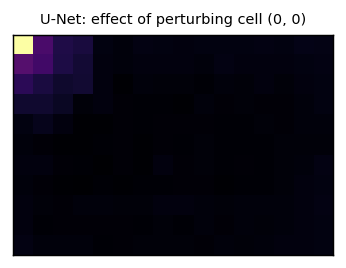

In [20]:
unet = UNet(hidden_channels=12)
nn.init.normal_(unet.head.weight, std=0.1)

u1 = to_nca_state(torch.as_tensor(unique[:1]), 12)
u2 = u1.clone()
u2[0, :, 0, 0] += 5.0
u_diff = (unet(u1) - unet(u2)).abs().sum(1)[0].detach()

nca_corner = (probe(s1) - probe(s2)).abs().sum(1)[0][-1, -1].detach()
print(f"NCA   parameters: {sum(p.numel() for p in nca.parameters()):>9,}")
print(f"U-Net parameters: {sum(p.numel() for p in unet.parameters()):>9,}")
print(f"\neffect of perturbing a corner cell on the opposite corner:")
print(f"  NCA   (one step): {float(nca_corner):.6f}")
print(f"  U-Net (one pass): {float(u_diff[-1, -1]):.6f}")

fig, ax = plt.subplots(figsize=(3.2, 2.2))
ax.imshow(u_diff, cmap="inferno")
ax.set_title("U-Net: effect of perturbing cell (0, 0)", fontsize=8)
ax.set_xticks([]); ax.set_yticks([])

## 20. The sample pool

The pool does not hold rooms, it holds states in mid-evolution. Every slot stores a state
that keeps changing and the target it should converge to, which is what allows a single
unconditioned model to handle many rooms.

All slots start identical. The diversity accumulates, because slots are drawn at random,
damaged or not, evolved for a variable number of steps, and written back. Without it the
model would only ever see the trajectory that starts from a clean room; the pool forces
it to recover from states it produced itself, which is what turns the target into a
stable attractor.

In [21]:
pool = SamplePool(train_aug, pool_size=1024, hidden_channels=12, device="cpu", seed=42)
print(f"slots: {pool.pool_size}, distinct rooms: {len(train_aug)}")
print(f"state  {tuple(pool.state.shape)}")
print(f"target {tuple(pool.target.shape)}")

slots: 1024, distinct rooms: 384
state  (1024, 22, 11, 16)
target (1024, 11, 16)


## 21. Training the cellular rule

Eight thousand iterations, roughly eighteen minutes on a T4. The loss plateaus before
that point, which matters for the interpretation: when access repair turns out to be low,
it is not because the model is undertrained.

In [22]:
NCA_RUN = os.path.join(RUNS_DIR, "m2_seed1")

if not SKIP_TRAINING_NCA:
    subprocess.run(["python", "scripts/train.py", "seed=1",
                    f"hydra.run.dir={NCA_RUN}"])
else:
    print(f"loading from {NCA_RUN}")

ckpt = torch.load(os.path.join(NCA_RUN, "last.pt"), map_location=device)
nca_trained = NCA(hidden_channels=12).to(device)
nca_trained.load_state_dict(ckpt["nca"])
nca_trained.eval()
print(f"checkpoint at step {ckpt['step']}")

loading from /kaggle/working/runs/m2_seed1
checkpoint at step 8000


## 22. Training curve

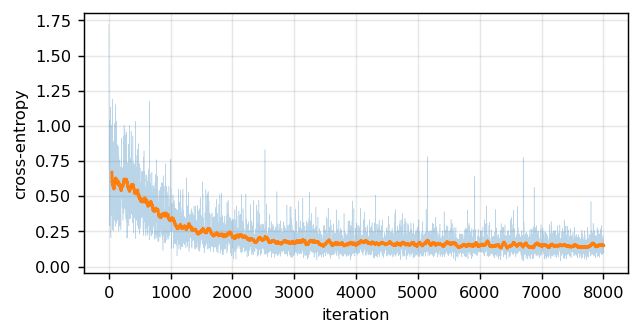

iterations 6000-7000: 0.1521
iterations 7000-8000: 0.1477


In [23]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(NCA_RUN)
ea.Reload()
scalars = ea.Scalars("loss/train")
steps = np.array([s.step for s in scalars])
vals = np.array([s.value for s in scalars])
smooth = np.convolve(vals, np.ones(50) / 50, mode="valid")

fig, ax = plt.subplots(figsize=(5.4, 2.6))
ax.plot(steps, vals, lw=0.3, alpha=0.3)
ax.plot(steps[49:], smooth, lw=1.6)
ax.set_xlabel("iteration"); ax.set_ylabel("cross-entropy"); ax.grid(alpha=0.3)
plt.show()

print(f"iterations 6000-7000: {vals[(steps >= 6000) & (steps < 7000)].mean():.4f}")
print(f"iterations 7000-8000: {vals[steps >= 7000].mean():.4f}")

## 23. What repair looks like

The same room under two damages that destroy the same number of cells. In the first the
neighbourhood of the damage is floor, so the locally plausible completion is also the
correct one. In the second the neighbourhood is wall, and the model writes a wall.

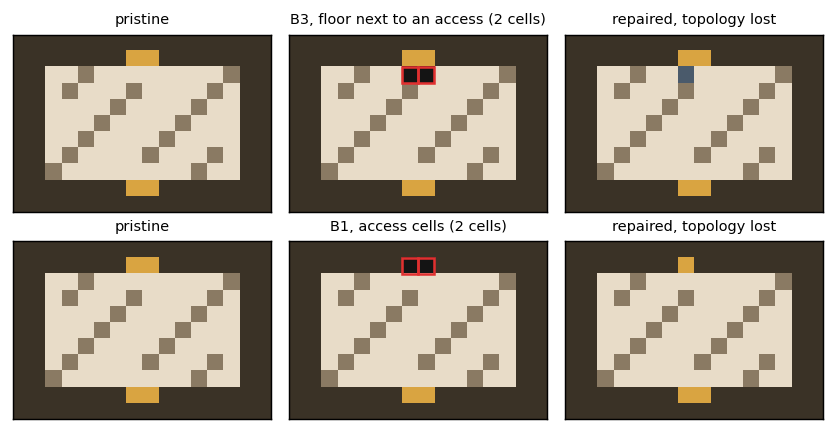

In [24]:
@torch.no_grad()
def repair(room, selector, seed=1, steps=96, **kw):
    rng = np.random.default_rng(seed)
    st = to_nca_state(torch.as_tensor(room).unsqueeze(0), 12).to(device)
    mask = selector(room, rng, **kw)
    st, _ = kill_cells(st, mask)
    damaged = decode(st)[0].cpu().numpy()
    for _ in range(steps):
        st = nca_trained(st)
    return damaged, decode(st)[0].cpu().numpy(), mask


candidates = [r for r in test
              if np.any(r == CHAR_MAP["F"]) and int(access_mask(r).sum()) >= 2]
target_room = candidates[0]
fig, axes = plt.subplots(2, 3, figsize=(6.5, 3.4))
for row, (name, selector, kw) in enumerate(
        [("B3, floor next to an access", TARGETED["B3_isolation"], {}),
         ("B1, access cells", TARGETED["B1_door"], {"n_doors": 1})]):
    damaged, repaired, mask = repair(target_room, selector, **kw)
    kept = preserves_topology(target_room, repaired)
    render_room(target_room, axes[row][0], "pristine")
    render_room(damaged, axes[row][1], f"{name} ({int(mask.sum())} cells)", highlight=mask)
    render_room(repaired, axes[row][2],
                f"repaired, topology {'kept' if kept else 'lost'}")
plt.tight_layout()

## 24. Evaluation on the test split

The suite covers stochastic damage at eight extents, the matched-extent control, and the
targeted conditions. Every model is evaluated on the same rooms with the same damage
seeds, so that differences between models are not differences in where the damage landed.

In [25]:
def evaluate_run(run_name, split="test", steps=None):
    ckpt_path = os.path.join(RUNS_DIR, run_name, "last.pt")
    if not os.path.exists(ckpt_path):
        return False
    cmd = ["python", "scripts/evaluate.py", f"eval.ckpt={ckpt_path}",
           f"eval.split={split}",
           f"hydra.run.dir={os.path.join(BASE_DIR, 'eval', run_name)}"]
    if steps:
        cmd.append(f"eval.steps={steps}")
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
    return True


def read_run(run, split="test"):
    path = os.path.join(RUNS_DIR, run, f"eval_{split}.csv")
    if not os.path.exists(path):
        return {}
    with open(path) as f:
        return {r["damage"]: r for r in csv.DictReader(f)}


def aggregate(runs, label, conditions, split="test"):
    data = [d for d in (read_run(r, split) for r in runs) if d]
    if not data:
        print(f"{label:<24}no data"); return
    line = f"{label:<24}"
    for c in conditions:
        v = [float(d[c]["rsr_mean"]) for d in data if c in d]
        line += f"{np.mean(v):>8.3f}+-{np.std(v):<6.3f}" if v else f"{'-':>16}"
    print(line + f"   (n={len(data)})")


M1      = [f"m1_null_s{s}" for s in (1, 2, 3)]
M2      = ["m2_seed1"] + [f"m2_s{s}" for s in range(2, 9)]
UNET_16 = [f"unet_iter16_s{s}" for s in (1, 2, 3)]
UNET_1  = [f"unet_oneshot_s{s}" for s in (1, 2, 3)]
BFS     = [f"aux10_s{s}" for s in range(1, 9)]
GLOB    = [f"glob1_s{s}" for s in range(1, 9)]
COND    = ["A0_none", "A3_matched_random", "B1_door", "B3_isolation"]

for name in M1 + M2 + UNET_16 + UNET_1 + BFS + GLOB:
    steps = "1" if "oneshot" in name else ("16" if "iter16" in name else "96")
    evaluate_run(name, "test", steps)
print("evaluation complete")

evaluation complete


## 25. Damage during training induces regeneration

The first model never sees a damaged room, so its only task is persistence. It learns it
well, and repairs almost nothing.

In [26]:
print(f"{'model':<24}" + "".join(f"{c:>16}" for c in COND))
print("-" * (24 + 16 * len(COND)))
aggregate(M1, "no-damage NCA", COND)
aggregate(M2, "NCA", COND)

model                            A0_noneA3_matched_random         B1_door    B3_isolation
----------------------------------------------------------------------------------------
no-damage NCA              0.967+-0.047    0.328+-0.250    0.122+-0.161    0.189+-0.131    (n=3)
NCA                        0.973+-0.017    0.482+-0.172    0.100+-0.091    0.675+-0.115    (n=8)


## 26. The target of the damage, not its extent

The three conditions destroy the same number of cells. The ordering follows how far the
local neighbourhood agrees with the correct answer: floor surrounded by floor is both
locally and globally right, whereas an access is surrounded by walls, so a local rule
writes a wall there.

In [27]:
m2_data = [d for d in (read_run(r) for r in M2) if d]
ceiling = np.mean([float(d["A0_none"]["rsr_mean"]) for d in m2_data])

print(f"{'condition':<22}{'target of the K cells':<34}{'RSR':>10}{'% of ceiling':>14}")
print("-" * 80)
for cond, target in [("B3_isolation", "walkable cells next to an access"),
                     ("A3_matched_random", "random walkable cells"),
                     ("B1_door", "access cells")]:
    v = np.mean([float(d[cond]["rsr_mean"]) for d in m2_data])
    print(f"{cond:<22}{target:<34}{v:>10.3f}{100 * v / ceiling:>12.0f}%")

b1 = np.mean([float(d["B1_door"]["rsr_mean"]) for d in m2_data])
b3 = np.mean([float(d["B3_isolation"]["rsr_mean"]) for d in m2_data])
print(f"\nceiling (A0) = {ceiling:.3f}   ratio B3/B1 = {b3 / b1:.1f}x")

print(f"\n{'condition':<22}{'tile accuracy':>16}{'RSR':>10}")
print("-" * 48)
for cond in ["A0_none", "B3_isolation", "A3_matched_random", "B1_door"]:
    acc = np.mean([float(d[cond]["acc_mean"]) for d in m2_data])
    r = np.mean([float(d[cond]["rsr_mean"]) for d in m2_data])
    print(f"{cond:<22}{acc:>16.3f}{r:>10.3f}")

condition             target of the K cells                    RSR  % of ceiling
--------------------------------------------------------------------------------
B3_isolation          walkable cells next to an access       0.675          69%
A3_matched_random     random walkable cells                  0.482          50%
B1_door               access cells                           0.100          10%

ceiling (A0) = 0.973   ratio B3/B1 = 6.7x

condition                tile accuracy       RSR
------------------------------------------------
A0_none                          1.000     0.973
B3_isolation                     0.997     0.675
A3_matched_random                0.995     0.482
B1_door                          0.989     0.100


## 27. Degradation under stochastic damage

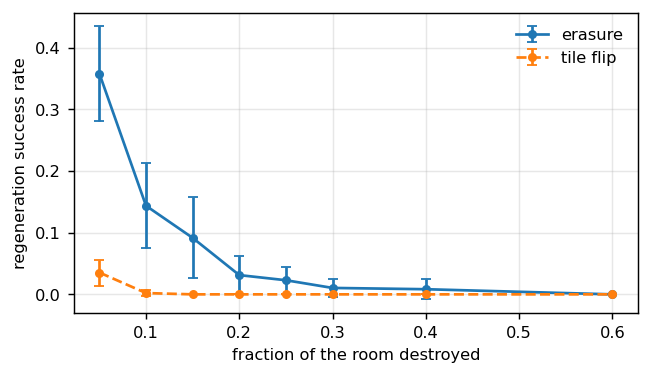

0.05->0.358  0.10->0.144  0.15->0.092  0.20->0.031  0.25->0.023  0.30->0.010  0.40->0.008  0.60->0.000


In [28]:
def curve(runs, damage="A1_erasure", split="test"):
    by_extent = {}
    for r in runs:
        path = os.path.join(RUNS_DIR, r, f"eval_{split}.csv")
        if not os.path.exists(path):
            continue
        with open(path) as f:
            for row in csv.DictReader(f):
                if row["damage"] == damage:
                    by_extent.setdefault(float(row["extent"]), []).append(
                        float(row["rsr_mean"]))
    x = sorted(by_extent)
    return x, [np.mean(by_extent[k]) for k in x], [np.std(by_extent[k]) for k in x]


fig, ax = plt.subplots(figsize=(5.6, 3))
for damage, label, ls in [("A1_erasure", "erasure", "-"), ("A2_tileflip", "tile flip", "--")]:
    x, m, s = curve(M2, damage)
    if x:
        ax.errorbar(x, m, yerr=s, marker="o", capsize=3, lw=1.5, ms=4, ls=ls, label=label)
ax.set_xlabel("fraction of the room destroyed")
ax.set_ylabel("regeneration success rate")
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.show()

x, m, _ = curve(M2)
print("  ".join(f"{a:.2f}->{b:.3f}" for a, b in zip(x, m)))

## 28. Ablations

Every alternative explanation for the failure on access repair: capacity, propagation
horizon, update stochasticity, rule width and perception. None of them moves it, while
several improve stability and the locally consistent conditions. Reported on validation,
since we used them to understand the model rather than to produce final numbers.

In [29]:
HIDDEN = {h: [f"h{h}_s{s}" for s in (1, 2, 3)] for h in (8, 16, 24)}
BPTT   = {b: [f"bp{b}_s{s}" for s in (1, 2, 3)] for b in (64, 128)}
UPDATE = {"0.3": [f"up03_s{s}" for s in (1, 2, 3)], "0.7": [f"up07_s{s}" for s in (1, 2, 3)]}
MLP    = {m: [f"mlp{m}_s{s}" for s in (1, 2, 3)] for m in (64, 256)}
LAP    = [f"lap_s{s}" for s in range(1, 9)]

if not SKIP_TRAINING_ABLATIONS:
    print("training the ablation sweep takes several hours; set the flag to False to run it")

for name in sum(HIDDEN.values(), []) + sum(BPTT.values(), []) + sum(UPDATE.values(), []) \
            + sum(MLP.values(), []) + LAP + M2 + GLOB:
    evaluate_run(name, "val")

print(f"{'configuration':<24}" + "".join(f"{c:>16}" for c in COND))
print("-" * (24 + 16 * len(COND)))
aggregate(HIDDEN[8], "hidden = 8", COND, "val")
aggregate(M2, "hidden = 12 (base)", COND, "val")
aggregate(HIDDEN[16], "hidden = 16", COND, "val")
aggregate(HIDDEN[24], "hidden = 24", COND, "val")
print()
aggregate(BPTT[64], "unroll <= 64", COND, "val")
aggregate(BPTT[128], "unroll <= 128", COND, "val")
aggregate(UPDATE["0.3"], "update prob. 0.3", COND, "val")
aggregate(UPDATE["0.7"], "update prob. 0.7", COND, "val")
aggregate(MLP[64], "MLP width 64", COND, "val")
aggregate(MLP[256], "MLP width 256", COND, "val")
aggregate(LAP, "with Laplacian", COND, "val")

configuration                    A0_noneA3_matched_random         B1_door    B3_isolation
----------------------------------------------------------------------------------------
hidden = 8                 0.883+-0.027    0.713+-0.071    0.217+-0.121    0.767+-0.027    (n=3)
hidden = 12 (base)         0.967+-0.034    0.524+-0.132    0.090+-0.066    0.713+-0.103    (n=8)
hidden = 16                0.967+-0.024    0.417+-0.096    0.083+-0.049    0.628+-0.079    (n=3)
hidden = 24                1.000+-0.000    0.503+-0.084    0.067+-0.014    0.594+-0.048    (n=3)

unroll <= 64               0.967+-0.027    0.517+-0.097    0.228+-0.146    0.700+-0.082    (n=3)
unroll <= 128              0.983+-0.014    0.526+-0.088    0.033+-0.036    0.750+-0.108    (n=3)
update prob. 0.3           0.939+-0.021    0.537+-0.068    0.028+-0.021    0.622+-0.089    (n=3)
update prob. 0.7           0.994+-0.008    0.562+-0.127    0.178+-0.021    0.756+-0.055    (n=3)
MLP width 64               0.889+-0.048    0

## 29. A note on low-seed variance

The Laplacian is the clearest case of why the main comparisons use eight paired seeds
rather than three: at three seeds the two arms are ordered one way, at eight the other,
and the spread is larger than the mean.

In [30]:
def b1_stat(runs, split="val"):
    v = [float(read_run(r, split)["B1_door"]["rsr_mean"]) for r in runs if read_run(r, split)]
    return (np.mean(v), np.std(v), len(v)) if v else (np.nan, np.nan, 0)


for n in (3, 8):
    ms, ss, ns = b1_stat(M2[:n])
    ml, sl, nl = b1_stat(LAP[:n])
    print(f"{n} seeds:  Sobel {ms:.3f}+-{ss:.3f} (n={ns})   "
          f"Laplacian {ml:.3f}+-{sl:.3f} (n={nl})")

3 seeds:  Sobel 0.122+-0.048 (n=3)   Laplacian 0.044+-0.008 (n=3)
8 seeds:  Sobel 0.090+-0.066 (n=8)   Laplacian 0.127+-0.152 (n=8)


## 30. Locality against a global view

With capacity, horizon and perception ruled out, the remaining candidate is the locality
of the rule. The U-Net is used in two regimes, because the cellular rule is both local
and iterative and comparing against a single global model would move two variables at
once.

The outcome is a double dissociation: on the locally consistent conditions the iterative
models lead and the one-shot model is worst, and on access repair the ordering reverses.
Neither receptive field dominates.

In [31]:
print(f"{'model':<24}" + "".join(f"{c:>16}" for c in COND))
print("-" * (24 + 16 * len(COND)))
aggregate(M2, "NCA (local, 96 steps)", COND)
aggregate(UNET_16, "iterative U-Net", COND)
aggregate(UNET_1, "one-shot U-Net", COND)

model                            A0_noneA3_matched_random         B1_door    B3_isolation
----------------------------------------------------------------------------------------
NCA (local, 96 steps)      0.973+-0.017    0.482+-0.172    0.100+-0.091    0.675+-0.115    (n=8)
iterative U-Net            0.950+-0.041    0.817+-0.155    0.156+-0.119    0.928+-0.055    (n=3)
one-shot U-Net             1.000+-0.000    0.150+-0.024    0.506+-0.132    0.222+-0.039    (n=3)


## 31. Making the topological signal explicit

One hidden channel is supervised towards the geodesic distance to the nearest access,
computed on the pristine room. No channel is added, so the model has the same
architecture and the same parameter count as the baseline and the loss term is the only
difference. The field comes from the pristine room while the input is damaged, so the
model has to infer the correct topology rather than copy it.

model                            A0_noneA3_matched_random         B1_door    B3_isolation
----------------------------------------------------------------------------------------
NCA                        0.973+-0.017    0.482+-0.172    0.100+-0.091    0.675+-0.115    (n=8)
BFS-supervised NCA         0.917+-0.041    0.578+-0.131    0.152+-0.090    0.783+-0.038    (n=8)


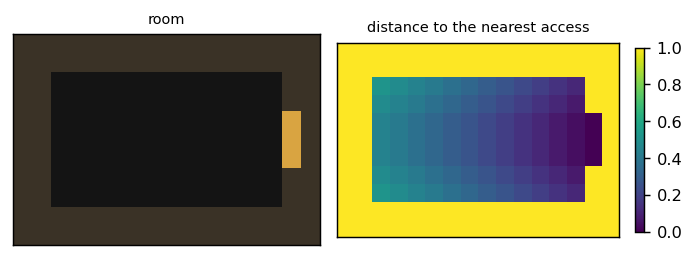

In [32]:
field = access_distance_field(unique[0])

fig, axes = plt.subplots(1, 2, figsize=(5.5, 2))
render_room(unique[0], axes[0], "room")
im = axes[1].imshow(field, cmap="viridis")
axes[1].set_title("distance to the nearest access", fontsize=8)
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], fraction=0.03)
plt.tight_layout()

print(f"{'model':<24}" + "".join(f"{c:>16}" for c in COND))
print("-" * (24 + 16 * len(COND)))
aggregate(M2, "NCA", COND)
aggregate(BFS, "BFS-supervised NCA", COND)

## 32. Relaxing locality with a global channel

A minimal relaxation: one hidden channel is replaced, after every step, by its spatial
mean and redistributed to every cell. Each cell still reads only its own neighbourhood,
but it also receives a scalar summary of the global state, at the same parameter count.

The trade-off is the same as the one-shot model's but smaller. What changes is where the
model sits between local and global, rather than how good it is.

In [33]:
print(f"{'model':<24}" + "".join(f"{c:>16}" for c in COND))
print("-" * (24 + 16 * len(COND)))
aggregate(M2, "NCA (local)", COND)
aggregate(GLOB, "global-channel NCA", COND)
aggregate(UNET_1, "one-shot U-Net", COND)

g1 = np.mean([float(read_run(r)["B1_door"]["rsr_mean"]) for r in GLOB if read_run(r)])
u1 = np.mean([float(read_run(r)["B1_door"]["rsr_mean"]) for r in UNET_1 if read_run(r)])
print(f"\nagainst the local rule on access repair:")
print(f"  global channel: {g1 / b1:.1f}x")
print(f"  one-shot U-Net: {u1 / b1:.1f}x")

model                            A0_noneA3_matched_random         B1_door    B3_isolation
----------------------------------------------------------------------------------------
NCA (local)                0.973+-0.017    0.482+-0.172    0.100+-0.091    0.675+-0.115    (n=8)
global-channel NCA         0.971+-0.025    0.268+-0.206    0.273+-0.155    0.477+-0.221    (n=8)
one-shot U-Net             1.000+-0.000    0.150+-0.024    0.506+-0.132    0.222+-0.039    (n=3)

against the local rule on access repair:
  global channel: 2.7x
  one-shot U-Net: 5.1x


## 33. Summary

The table reported in the paper, on the held-out test split.

In [34]:
print(f"{'model':<24}" + "".join(f"{c:>16}" for c in COND))
print("-" * (24 + 16 * len(COND)))
aggregate(M1, "no-damage NCA", COND)
aggregate(M2, "NCA", COND)
aggregate(UNET_16, "iterative U-Net", COND)
aggregate(UNET_1, "one-shot U-Net", COND)
aggregate(BFS, "BFS NCA", COND)
aggregate(GLOB, "global-channel NCA", COND)

model                            A0_noneA3_matched_random         B1_door    B3_isolation
----------------------------------------------------------------------------------------
no-damage NCA              0.967+-0.047    0.328+-0.250    0.122+-0.161    0.189+-0.131    (n=3)
NCA                        0.973+-0.017    0.482+-0.172    0.100+-0.091    0.675+-0.115    (n=8)
iterative U-Net            0.950+-0.041    0.817+-0.155    0.156+-0.119    0.928+-0.055    (n=3)
one-shot U-Net             1.000+-0.000    0.150+-0.024    0.506+-0.132    0.222+-0.039    (n=3)
BFS NCA                    0.917+-0.041    0.578+-0.131    0.152+-0.090    0.783+-0.038    (n=8)
global-channel NCA         0.971+-0.025    0.268+-0.206    0.273+-0.155    0.477+-0.221    (n=8)


The repair of a damaged room succeeds or fails according to the target of the damage
rather than its extent, and the cause is the locality of the rule: capacity, propagation
horizon, perception and explicit topological supervision leave it unchanged, while a
single global pass, or a single scalar shared across the grid, recovers a large part of
the gap. A criterion based on pathfinding exposes failures that per-tile accuracy does
not register.